# Training Statistics Visualization

This notebook visualizes the training progress using data from `training_stats_HEURISTIC_DFS.json`.

In [36]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style for aesthetics
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

In [37]:
# Configuration
STATS_FILE = 'training_stats_MLP.json'
WINDOW_SIZE = 100  # Rolling average window

In [51]:
# Load Data
if os.path.exists(STATS_FILE):
    with open(STATS_FILE, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} episodes.")
    display(df.tail())
else:
    print(f"File {STATS_FILE} not found!")
    df = pd.DataFrame()

Loaded 24245 episodes.


,episode,reward,visited_ratio
24240,24241,-22.8,0.772727
24241,24242,-30.0,0.916667
24242,24243,-32.4,0.450000
24243,24244,-24.0,0.842105
24244,24245,-27.6,0.812500


In [52]:
df = df.loc[df['episode'] < 6000]

In [53]:
# df = df.loc[df['reward'] > 5]

In [54]:
# Calculate Rolling Averages
if not df.empty:
    df['reward_ma'] = df['reward'].rolling(window=WINDOW_SIZE, min_periods=1).mean()
    # df['visited_ratio_ma'] = df['visited_ratio'].rolling(window=WINDOW_SIZE, min_periods=1).mean()

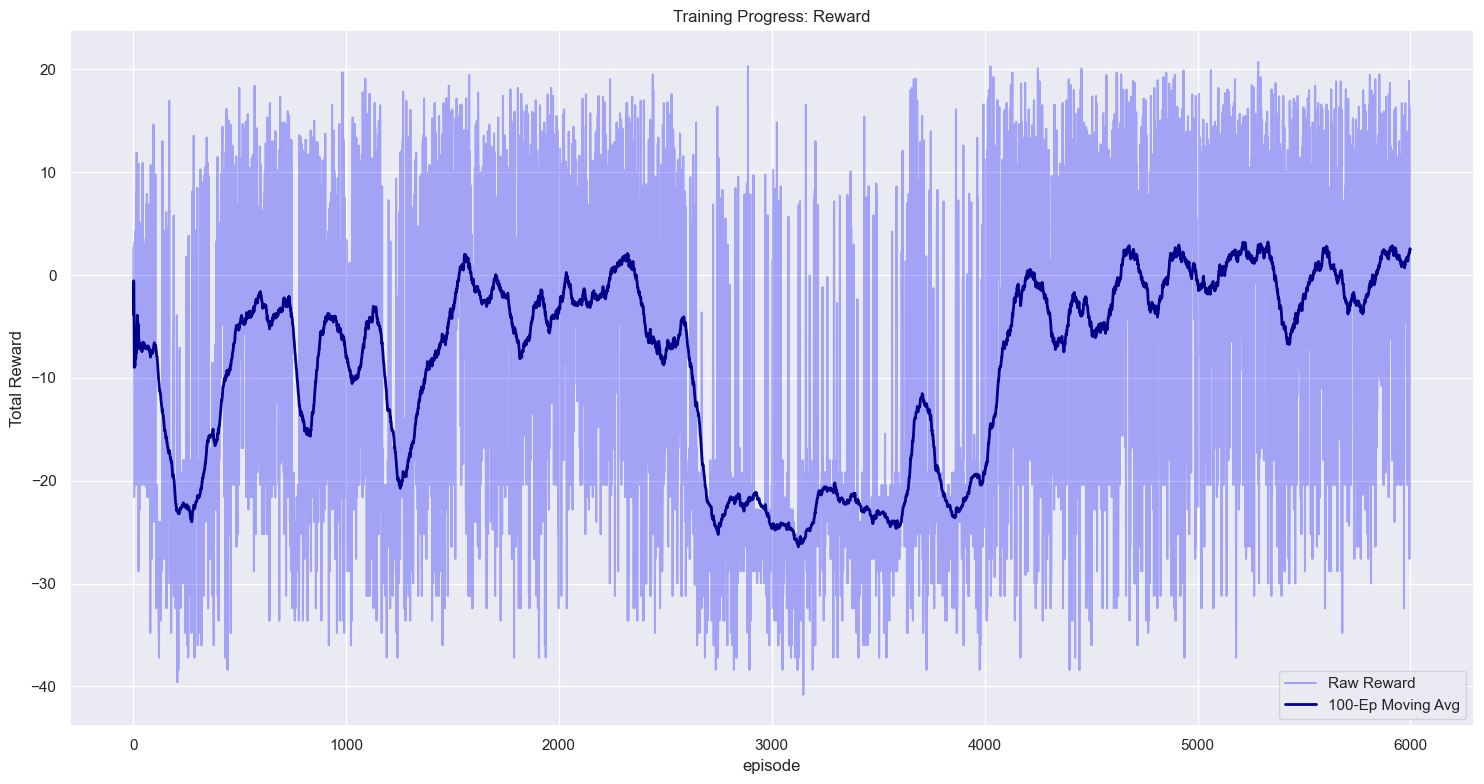

In [55]:
# Plotting
if not df.empty:
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 8))

    # Plot 1: Value / Reward
    sns.lineplot(data=df, x='episode', y='reward', ax=ax1, alpha=0.3, color='blue', label='Raw Reward')
    sns.lineplot(data=df, x='episode', y='reward_ma', ax=ax1, color='darkblue', linewidth=2, label=f'{WINDOW_SIZE}-Ep Moving Avg')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('Training Progress: Reward')
    ax1.legend()

    plt.tight_layout()
    plt.show()